In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Experiments_KFolds\Animals-3\models_log.csv")
df.columns

Index(['k-fold', 'vanillaNAS_dense_param_count',
       'JimmyNAS_I_fullyCNN_param_count', 'vanillaNAS_dense_best_acc',
       'JimmyNAS_I_fullyCNN_best_acc', 'vanillaNAS_dense_mac_count',
       'JimmyNAS_I_fullyCNN_mac_count', 'vanillaNAS_dense_flash',
       'JimmyNAS_I_fullyCNN_flash', 'vanillaNAS_dense_peak_ram',
       'JimmyNAS_I_fullyCNN_peak_ram', 'vanillaNAS_dense_tflite_acc',
       'JimmyNAS_I_fullyCNN_tflite_acc', 'vanillaNAS_dense_tflite_precision',
       'JimmyNAS_I_fullyCNN_tflite_precision',
       'vanillaNAS_dense_tflite_recall', 'JimmyNAS_I_fullyCNN_tflite_recall',
       'vanillaNAS_dense_tflite_f1', 'JimmyNAS_I_fullyCNN_tflite_f1'],
      dtype='object')

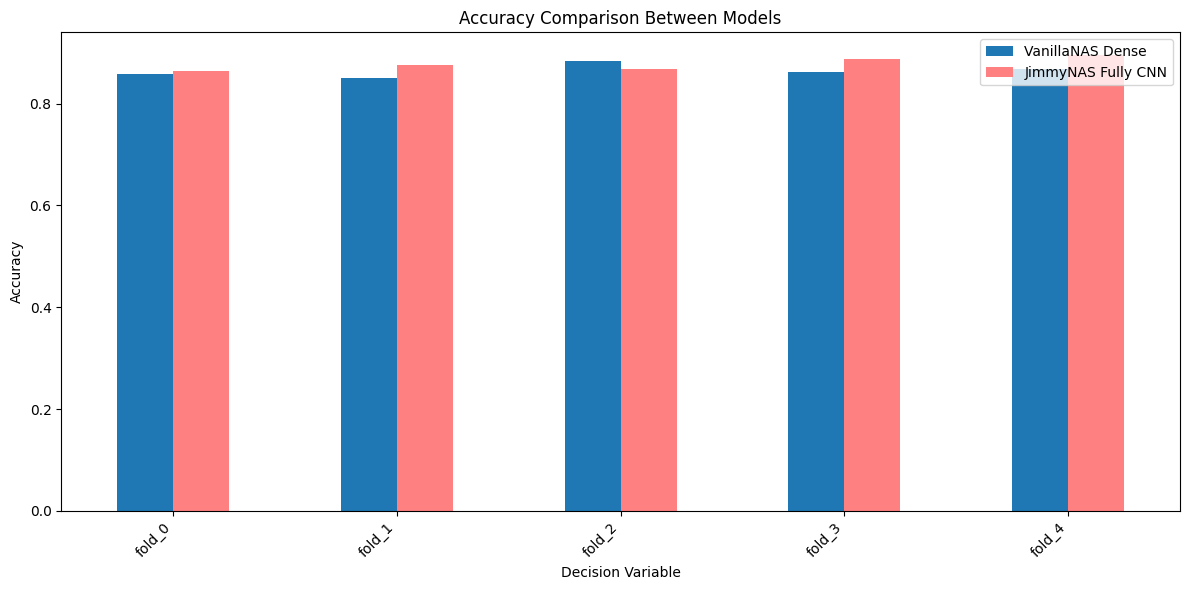

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_best_acc", "JimmyNAS_I_fullyCNN_best_acc"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.xlabel("Decision Variable")
plt.title("Accuracy Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# win 5   lose 5


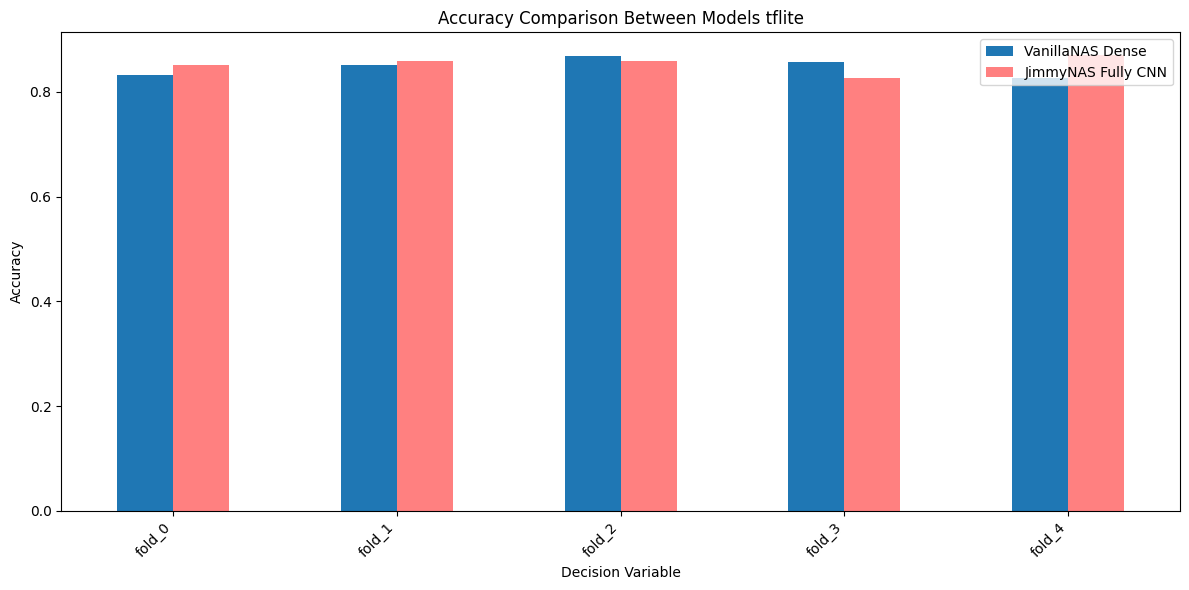

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_tflite_acc", "JimmyNAS_I_fullyCNN_tflite_acc"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.xlabel("Decision Variable")
plt.title("Accuracy Comparison Between Models tflite")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()


# win 5   lose 5

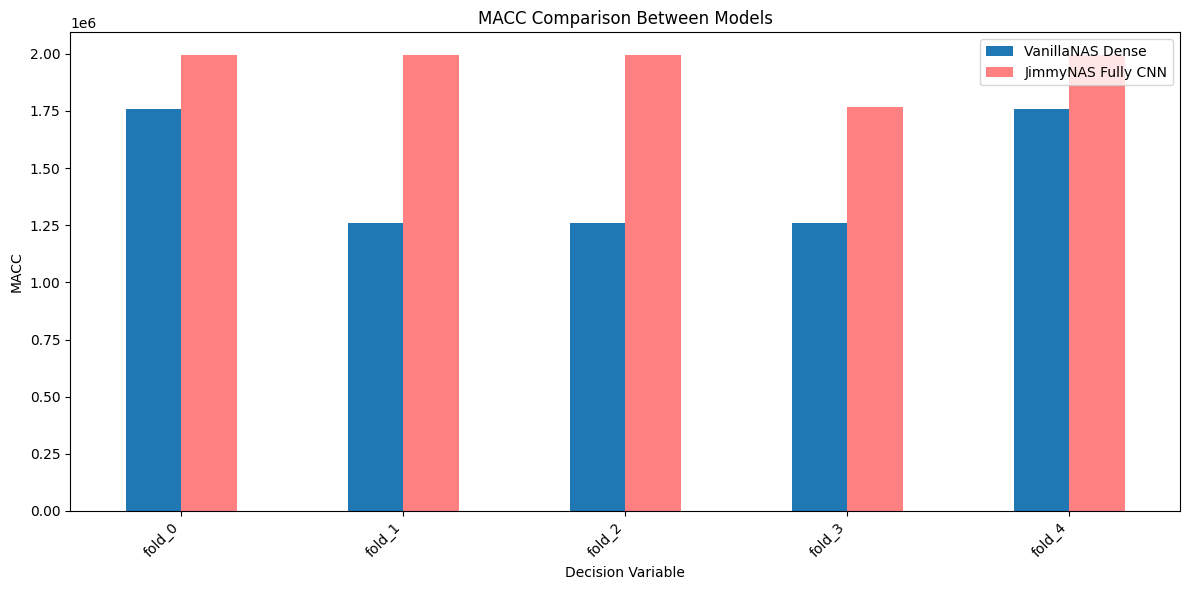

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_mac_count", "JimmyNAS_I_fullyCNN_mac_count"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("MACC")
plt.xlabel("Decision Variable")
plt.title("MACC Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# MACC jimmy ใช้เยอะกว่า baseline จากโดยรวม


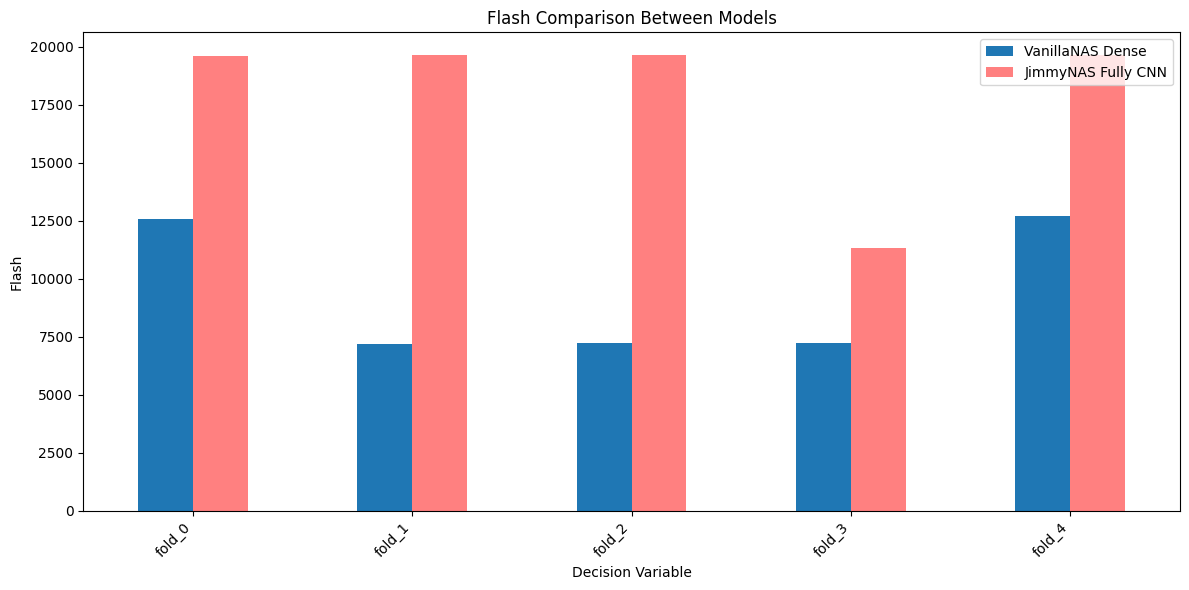

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_flash", "JimmyNAS_I_fullyCNN_flash"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Flash")
plt.xlabel("Decision Variable")
plt.title("Flash Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# Flash ของ baseline ใช้เยอะกว่า Jimmy อย่างเห็นได้ชัด

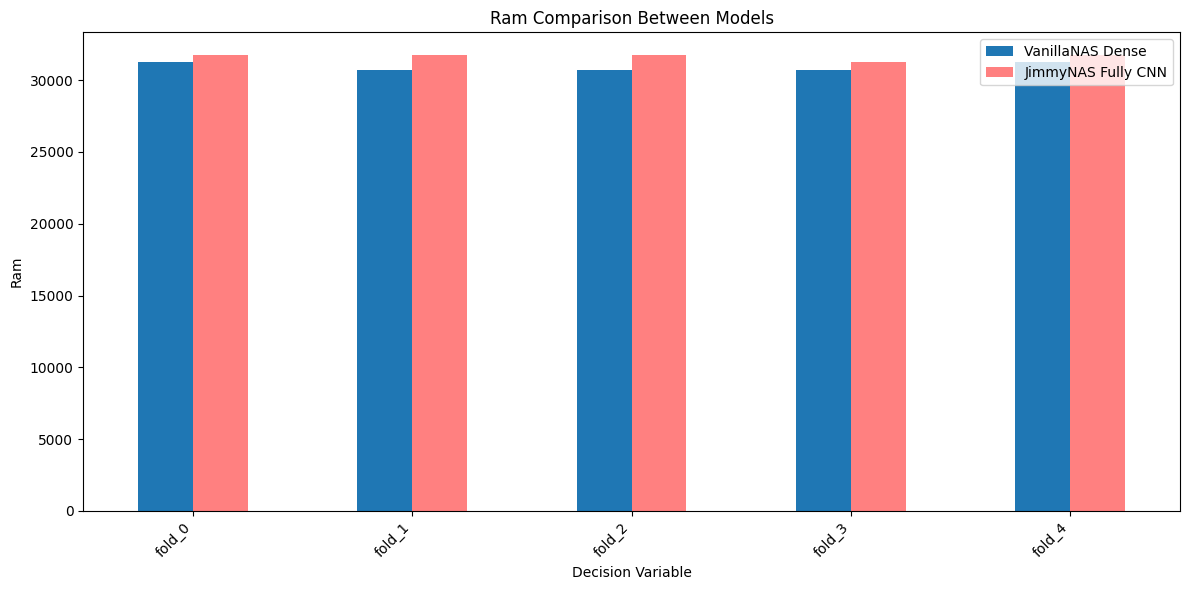

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_peak_ram", "JimmyNAS_I_fullyCNN_peak_ram"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Ram")
plt.xlabel("Decision Variable")
plt.title("Ram Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# Ram ในบางช่วง Jimmy จะใช้เยอะกว่าเมื่อมีเลเยอร์ต่ำ

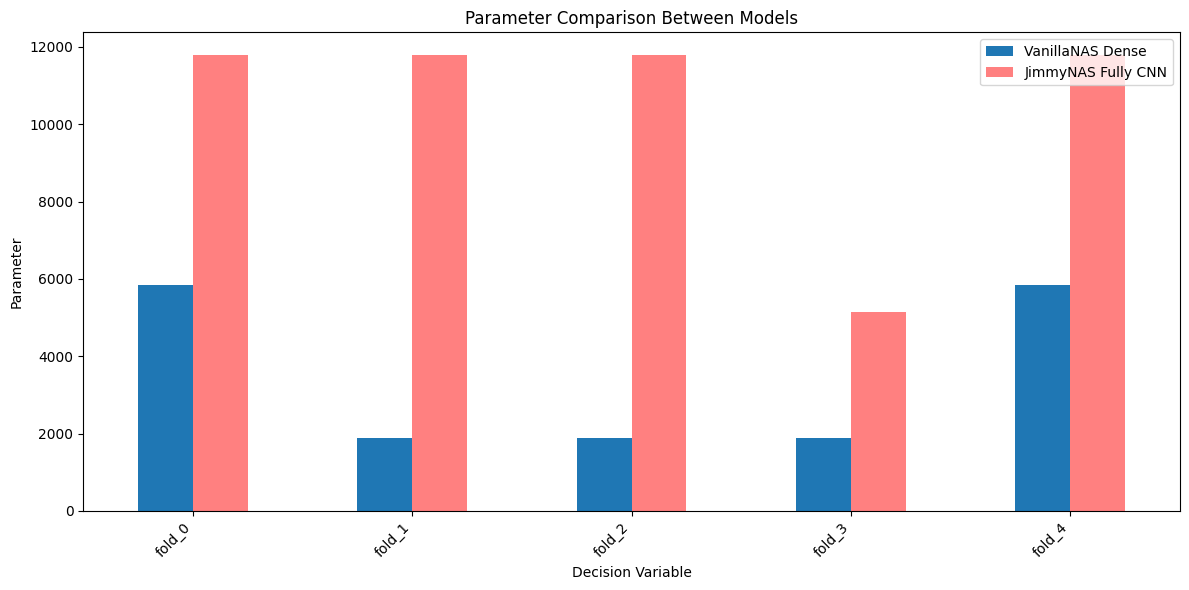

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df.plot(
    x="k-fold",
    y=["vanillaNAS_dense_param_count", "JimmyNAS_I_fullyCNN_param_count"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Parameter")
plt.xlabel("Decision Variable")
plt.title("Parameter Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# parameter ของ baseline จะมีจำนวน parameter เยอะกว่า Jimmy

In [ ]:
# win 5   lose 5  full
# win 5   lose 5  tflite
# MACC jimmy ใช้เยอะกว่า baseline จากโดยรวม
# Flash ของ baseline ใช้เยอะกว่า Jimmy อย่างเห็นได้ชัด
# Ram ในบางช่วง Jimmy จะใช้เยอะกว่าเมื่อมีเลเยอร์ต่ำ
# parameter ของ baseline จะมีจำนวน parameter เยอะกว่า Jimmy

In [14]:
df_cmp = df.copy()
metrics = [
    "best_acc",
    "tflite_acc",
    "mac_count",
    "flash",
    "peak_ram",
    "param_count"
]
higher_better = ["best_acc", "tflite_acc"]

for m in metrics:
    v_col = f"vanillaNAS_dense_{m}"
    j_col = f"JimmyNAS_I_fullyCNN_{m}"

    if m in higher_better:
        df_cmp[f"{m}_result"] = (
            (df_cmp[j_col] > df_cmp[v_col]).map({True: "Win", False: "Lose"})
        )
    else:
        df_cmp[f"{m}_result"] = (
            (df_cmp[j_col] < df_cmp[v_col]).map({True: "Win", False: "Lose"})
        )

    # Handle Draws
    df_cmp.loc[df_cmp[j_col] == df_cmp[v_col], f"{m}_result"] = "Draw"

result_cols = [f"{m}_result" for m in metrics]

df_cmp["overall_result"] = (
    df_cmp[result_cols]
    .apply(lambda r: 
           "Win" if (r == "Win").sum() > (r == "Lose").sum()
           else "Lose" if (r == "Lose").sum() > (r == "Win").sum()
           else "Draw",
           axis=1)
)

cols_to_show = ["k-fold"] + result_cols + ["overall_result"]
df_cmp[cols_to_show]

# Win → JimmyNAS better

# Lose → VanillaNAS better

# Draw → Same value

,k-fold,best_acc_result,tflite_acc_result,mac_count_result,flash_result,peak_ram_result,param_count_result,overall_result
0,fold_0,Win,Win,Lose,Lose,Lose,Lose,Lose
1,fold_1,Win,Win,Lose,Lose,Lose,Lose,Lose
2,fold_2,Lose,Lose,Lose,Lose,Lose,Lose,Lose
3,fold_3,Win,Lose,Lose,Lose,Lose,Lose,Lose
4,fold_4,Win,Win,Lose,Lose,Lose,Lose,Lose


In [15]:
df.set_index("k-fold", inplace=True)

In [30]:
df.iloc[:, df.columns.str.startswith("vanillaNAS")].mean().map(lambda x: round(x, 2))

vanillaNAS_dense_param_count            3471.00
vanillaNAS_dense_best_acc                  0.86
vanillaNAS_dense_mac_count           1459458.60
vanillaNAS_dense_flash                  9400.00
vanillaNAS_dense_peak_ram              30924.80
vanillaNAS_dense_tflite_acc                0.85
vanillaNAS_dense_tflite_precision          0.86
vanillaNAS_dense_tflite_recall             0.84
vanillaNAS_dense_tflite_f1                 0.85
dtype: float64

In [33]:
df.iloc[:, df.columns.str.startswith("JimmyNAS")].mean().map(lambda x: round(x, 2))

JimmyNAS_I_fullyCNN_param_count           10457.40
JimmyNAS_I_fullyCNN_best_acc                  0.88
JimmyNAS_I_fullyCNN_mac_count           1948953.60
JimmyNAS_I_fullyCNN_flash                 17972.80
JimmyNAS_I_fullyCNN_peak_ram              31641.60
JimmyNAS_I_fullyCNN_tflite_acc                0.85
JimmyNAS_I_fullyCNN_tflite_precision          0.86
JimmyNAS_I_fullyCNN_tflite_recall             0.86
JimmyNAS_I_fullyCNN_tflite_f1                 0.86
dtype: float64

In [65]:
df_compare = pd.DataFrame(columns=["vanillaNAS", "JimmyNAS"],
                          index=["param_count", "acc", "mac", "flash", "peak_ram", "tflite_acc", "tflite_precision", "tflite_recall", "tflite_f1"])
df_compare["vanillaNAS"] = df.iloc[:, df.columns.str.startswith("vanillaNAS")].mean().map(lambda x: round(x, 2)).values
df_compare["JimmyNAS"] = df.iloc[:, df.columns.str.startswith("JimmyNAS")].mean().map(lambda x: round(x, 2)).values
df_compare["diff"] = abs(df_compare["vanillaNAS"] - df_compare["JimmyNAS"])
df_compare

,vanillaNAS,JimmyNAS,diff
param_count,3471.00,10457.40,6986.40
acc,0.86,0.88,0.02
mac,1459458.60,1948953.60,489495.00
flash,9400.00,17972.80,8572.80
peak_ram,30924.80,31641.60,716.80
tflite_acc,0.85,0.85,0.00
tflite_precision,0.86,0.86,0.00
tflite_recall,0.84,0.86,0.02
tflite_f1,0.85,0.86,0.01
